Problem - 1A - Single Year HDI Exploration

TASK:1 - Extracting Latest Year

In [1]:
import pandas as pd
import numpy as np
# Load dataset
df = pd.read_csv("Human_Development_Index_Dataset.csv", index_col = 0, encoding="latin1")

In [2]:
# Identify unique years
df['year'].unique()

array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [3]:
# Filter dataset for year 2022
hdi_2022_df = df[df['year'] == 2022].copy()

In [ ]:
# Save for later use
hdi_2022_df.to_csv('hdi_2022.csv', index=False)
print("File saved as 'hdi_2022.csv' in Colab storage")

File saved as 'hdi_2022.csv' in Colab storage


Task:2 - Data Exploration


In [ ]:
# First 10 rows
hdi_2022_df.head(10)

,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,life_expec_m,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,59.766,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,74.502,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,75.853,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,81.430,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,59.351,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,76.507,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,72.851,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
264,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,67.866,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,81.708,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,80.150,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621


In [ ]:
# Rows and columns
hdi_2022_df.shape

(206, 29)

In [ ]:
# Column names and data types
hdi_2022_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206 entries, 33 to 6798
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   iso3                       206 non-null    object 
 1   country                    206 non-null    object 
 2   year                       206 non-null    int64  
 3   hdi                        204 non-null    float64
 4   life_expectancy            206 non-null    float64
 5   pop_millions               206 non-null    float64
 6   hdi_f                      193 non-null    float64
 7   hdi_m                      193 non-null    float64
 8   life_expec_f               206 non-null    float64
 9   life_expec_m               206 non-null    float64
 10  expec_yr_school            205 non-null    float64
 11  expec_yr_school_f          205 non-null    float64
 12  expec_yr_school_m          205 non-null    float64
 13  mean_yr_school             204 non-null    float64
 1

Task:3 - Missing Values And Data Cleaning

In [ ]:
#Missing Values Count
hdi_2022_df.isna().sum()

,0
iso3,0
country,0
year,0
hdi,2
life_expectancy,0
pop_millions,0
hdi_f,13
hdi_m,13
life_expec_f,0
life_expec_m,0


In [ ]:
# Checking of duplicates
hdi_2022_df.duplicated().sum()

# Checking for non-numeric symbols in numeric columns
hdi_2022_df.select_dtypes(include='object').head()


,iso3,country
33,AFG,Afghanistan
66,ALB,Albania
99,DZA,Algeria
132,AND,Andorra
165,AGO,Angola


In [ ]:
# Identify columns to impute (those with missing values)
cols_to_impute = [
    'hdi', 'hdi_f', 'hdi_m', 'expec_yr_school', 'expec_yr_school_f',
    'expec_yr_school_m', 'mean_yr_school', 'mean_yr_school_f',
    'mean_yr_school_m', 'gross_inc_percap', 'gross_inc_percap_f',
    'gross_inc_percap_m', 'gender_development', 'gender_inequality',
    'secondary_education_f_%', 'secondary_education_m_%',
    'seats_in_parliament_f_%', 'seats_in_parliament_m_%',
    'labour_participation_f_%', 'labour_participation_m_%',
    'co2_emission_tons', 'mat_footprint_percap_tons'
]

# Store initial row count before imputation
initial_rows = hdi_2022_df.shape[0]

mask_to_drop = hdi_2022_df['iso3'].str.startswith('ZZ', na=False)
print(f"Rows to drop (aggregates): {mask_to_drop.sum()}")

hdi_2022_df = hdi_2022_df[~mask_to_drop].copy()
print(f"Rows after removing aggregates: {hdi_2022_df.shape[0]}")

# Impute each column with its median
for col in cols_to_impute:
    median_val = hdi_2022_df[col].median()
    hdi_2022_df[col] = hdi_2022_df[col].fillna(median_val)
    print(f"     - Imputed '{col}' with median: {median_val:.4f}")

rows_removed = initial_rows - hdi_2022_df.shape[0]
print(f"\n     Rows removed due to missing critical data (country, hdi, income): {rows_removed}")
print(f"     Final missing value count per column:")
print(hdi_2022_df.isnull().sum())

# Final Check
print(f"\n3. FINAL SHAPE AFTER CLEANING: {hdi_2022_df.shape}\nInitial shape was {initial_rows}, 30")

hdi_2022_df.to_csv("cleaned.csv", index=False)

Rows to drop (aggregates): 11
Rows after removing aggregates: 195
     - Imputed 'hdi' with median: 0.7400
     - Imputed 'hdi_f' with median: 0.7325
     - Imputed 'hdi_m' with median: 0.7499
     - Imputed 'expec_yr_school' with median: 13.3545
     - Imputed 'expec_yr_school_f' with median: 14.0164
     - Imputed 'expec_yr_school_m' with median: 13.1001
     - Imputed 'mean_yr_school' with median: 9.4237
     - Imputed 'mean_yr_school_f' with median: 9.5598
     - Imputed 'mean_yr_school_m' with median: 9.4699
     - Imputed 'gross_inc_percap' with median: 12360.8163
     - Imputed 'gross_inc_percap_f' with median: 9429.0715
     - Imputed 'gross_inc_percap_m' with median: 16126.7750
     - Imputed 'gender_development' with median: 0.9705
     - Imputed 'gender_inequality' with median: 0.3510
     - Imputed 'secondary_education_f_%' with median: 67.4550
     - Imputed 'secondary_education_m_%' with median: 69.7232
     - Imputed 'seats_in_parliament_f_%' with median: 24.9412
     - 

Task:4 - Basic Statistics

In [ ]:
#Computing of mean, median and standard deviation
mean_hdi = hdi_2022_df['hdi'].mean()
median_hdi = hdi_2022_df['hdi'].median()
std_hdi = hdi_2022_df['hdi'].std()

print("Mean is ", mean_hdi)
print("median is ", median_hdi)
print ("Standard Deviation is ", std_hdi)

Mean is  0.7239076923076924
median is  0.74
Standard Deviation is  0.15438408287001673


In [ ]:
#Country with the highest HDI in 2022
hdi_2022_df.loc[hdi_2022_df['hdi'].idxmax(), ['country', 'hdi']]

,5610
country,Switzerland
hdi,0.967


In [ ]:
#Country with the lowest HDI in 2022
hdi_2022_df.loc[hdi_2022_df['hdi'].idxmin(), ['country', 'hdi']]


,5346
country,Somalia
hdi,0.38


Task: 5 - Filtering and Sorting

In [ ]:
# Filter HDI > 0.800
high_hdi_df = hdi_2022_df[hdi_2022_df['hdi'] > 0.800]
print("Countries with HDI greater than 0.800 are ",high_hdi_df)

Countries with HDI greater than 0.800 are       iso3               country  year    hdi  life_expectancy  pop_millions  \
132   AND               Andorra  2022  0.884           83.552      0.079824   
198   ATG   Antigua and Barbuda  2022  0.826           79.236      0.093763   
231   ARG             Argentina  2022  0.849           76.064     45.510318   
297   AUS             Australia  2022  0.946           83.579     26.177414   
330   AUT               Austria  2022  0.926           82.412      8.939617   
...   ...                   ...   ...    ...              ...           ...   
5940  TUR               Türkiye  2022  0.855           78.475     85.341241   
6105  ARE  United Arab Emirates  2022  0.937           79.196      9.441128   
6138  GBR        United Kingdom  2022  0.940           82.156     67.508936   
6171  USA         United States  2022  0.927           78.203    338.289857   
6204  URY               Uruguay  2022  0.830           78.000      3.422794   

        

In [ ]:
# Sort by GNI per capita
high_hdi_sorted = high_hdi_df.sort_values(by='gross_inc_percap', ascending=False)
print("Filterd dataset by GNI per capita in descending order is ",high_hdi_sorted)

Filterd dataset by GNI per capita in descending order is       iso3              country  year    hdi  life_expectancy  pop_millions  \
3333  LIE        Liechtenstein  2022  0.942           84.656      0.039327   
4719  QAT                Qatar  2022  0.875           81.559      2.695122   
5214  SGP            Singapore  2022  0.949           84.133      5.975689   
2706  IRL              Ireland  2022  0.950           82.716      5.023109   
3399  LUX           Luxembourg  2022  0.927           82.591      0.647599   
...   ...                  ...   ...    ...              ...           ...   
198   ATG  Antigua and Barbuda  2022  0.826           79.236      0.093763   
528   BLR              Belarus  2022  0.801           73.246      9.534954   
5742  THA             Thailand  2022  0.803           79.680     71.697029   
2112  GEO              Georgia  2022  0.814           71.587      3.744385   
495   BRB             Barbados  2022  0.809           77.706      0.281635   

     

In [ ]:
# Top 10 countries
high_hdi_sorted.head(10)

,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,life_expec_m,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
3333,LIE,Liechtenstein,2022,0.942,84.656,0.039327,0.924163,0.974295,86.129,83.019,...,0.949,0.351,67.455002,69.723161,28.000000,72.000000,52.79,67.26,3.736776,9.7815
4719,QAT,Qatar,2022,0.875,81.559,2.695122,0.892561,0.869100,83.101,80.626,...,1.027,0.212,81.832741,71.417976,4.444444,95.555556,61.73,95.33,39.884274,63.5912
5214,SGP,Singapore,2022,0.949,84.133,5.975689,0.945325,0.954078,86.295,81.981,...,0.991,0.036,80.464020,85.932037,29.126214,70.873786,63.37,77.00,9.397481,43.1508
2706,IRL,Ireland,2022,0.950,82.716,5.023109,0.942838,0.951392,84.412,81.017,...,0.991,0.072,88.585639,86.417415,27.397260,72.602740,59.40,70.51,7.529751,26.3467
3399,LUX,Luxembourg,2022,0.927,82.591,0.647599,0.920482,0.927311,84.770,80.445,...,0.993,0.043,96.579350,89.328283,33.333333,66.666667,57.99,65.09,13.185395,49.1903
6105,ARE,United Arab Emirates,2022,0.937,79.196,9.441128,0.922940,0.936027,81.412,77.720,...,0.986,0.035,82.029137,86.145172,50.000000,50.000000,55.32,89.45,25.333276,28.1632
5610,CHE,Switzerland,2022,0.967,84.255,8.740472,0.949369,0.977383,85.932,82.484,...,0.971,0.018,96.939726,97.517437,39.024390,60.975610,61.49,71.94,4.117550,33.5913
4323,NOR,Norway,2022,0.966,83.393,5.434319,0.957148,0.970415,85.055,81.718,...,0.986,0.012,99.094031,99.274980,44.970414,55.029586,62.53,69.59,7.573541,32.0515
6171,USA,United States,2022,0.927,78.203,338.289857,0.927693,0.923405,81.015,75.479,...,1.005,0.180,95.424278,95.067093,28.060264,71.939736,56.79,67.97,14.932487,29.3498
2475,HKG,"Hong Kong, China (SAR)",2022,0.956,84.315,7.488865,0.942671,0.969515,86.893,81.754,...,0.972,0.351,77.866913,84.067802,24.941176,75.058824,52.91,64.71,4.373242,9.7815


Task:6 - Adding HDI Category Column

In [ ]:
def hdi_category(hdi):
    if hdi < 0.550:
        return "Low"
    elif hdi < 0.700:
        return "Medium"
    elif hdi < 0.800:
        return "High"
    else:
        return "Very High"

hdi_2022_df['HDI Category'] = hdi_2022_df['hdi'].apply(hdi_category)

In [ ]:
#Verification
hdi_2022_df['HDI Category'].value_counts()

,count
HDI Category,
Very High,69
High,51
Medium,42
Low,33


In [ ]:
# Save final CSV
hdi_2022_df.to_csv("HDI_category_added.csv", index=False)
print("Dataset with HDI Category column is saved as CSV")

Dataset with HDI Category column is saved as CSV


#Problem - 1B - HDI Visualization and Trend Analysis (2020 – 2022)


Task-1 : Data Extraction And Saving

In [ ]:
# Filter dataset for years 2020, 2021, 2022
hdi_problem1B = df[df['year'].isin([2020, 2021, 2022])].copy()

In [ ]:
# Saving the filtered dataset
hdi_problem1B.to_csv("HDI_problem1B.csv", index=False)

In [ ]:
#Using the cleaned dataset for all subsequent tasks
hdi_problem1B.shape

(618, 29)

Task-2: Data Cleaning

In [ ]:
#Checking for missing values
hdi_problem1B[['hdi', 'country', 'year']].isna().sum()


,0
hdi,8
country,0
year,0


In [ ]:
# Fix Inconsistent or Misspelled Country Names
hdi_problem1B['country'] = hdi_problem1B['country'].str.strip()

In [ ]:
#Identifying and addressing the issue
hdi_problem1B.duplicated().sum()

np.int64(0)

In [ ]:
#Applying and justifying the cleaning steps
# Convert HDI to numeric
hdi_problem1B['hdi'] = pd.to_numeric(hdi_problem1B['hdi'], errors='coerce')

# Convert GNI per capita if present
if 'gross inc percap' in hdi_problem1B.columns:
    hdi_problem1B['gross inc percap'] = pd.to_numeric(
        hdi_problem1B['gross inc percap'], errors='coerce'
    )


In [ ]:
#All cleaning decisions
hdi_problem1B.dropna(subset=['hdi', 'country', 'year'], inplace=True)
#duplicate removal
hdi_problem1B.drop_duplicates(inplace=True)

In [ ]:
# Display info to confirm cleaning
hdi_problem1B.info()

<class 'pandas.core.frame.DataFrame'>
Index: 610 entries, 31 to 6798
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   iso3                       610 non-null    object 
 1   country                    610 non-null    object 
 2   year                       610 non-null    int64  
 3   hdi                        610 non-null    float64
 4   life_expectancy            610 non-null    float64
 5   pop_millions               610 non-null    float64
 6   hdi_f                      577 non-null    float64
 7   hdi_m                      577 non-null    float64
 8   life_expec_f               610 non-null    float64
 9   life_expec_m               610 non-null    float64
 10  expec_yr_school            610 non-null    float64
 11  expec_yr_school_f          610 non-null    float64
 12  expec_yr_school_m          610 non-null    float64
 13  mean_yr_school             610 non-null    float64
 1

Task-3: Visualization Task


No. A: Line Chart — HDI Trend

In [ ]:
#Selecting Five countries
selected_countries = ['Nepal', 'India', 'Bangladesh', 'Sri Lanka', 'Pakistan']
country_trends = hdi_problem1B[
    hdi_problem1B['country'].isin(selected_countries)
]
selected_countries = ['Nepal', 'India', 'Bangladesh', 'Sri Lanka', 'Pakistan']
country_trends = hdi_problem1B[
    hdi_problem1B['country'].isin(selected_countries)
]


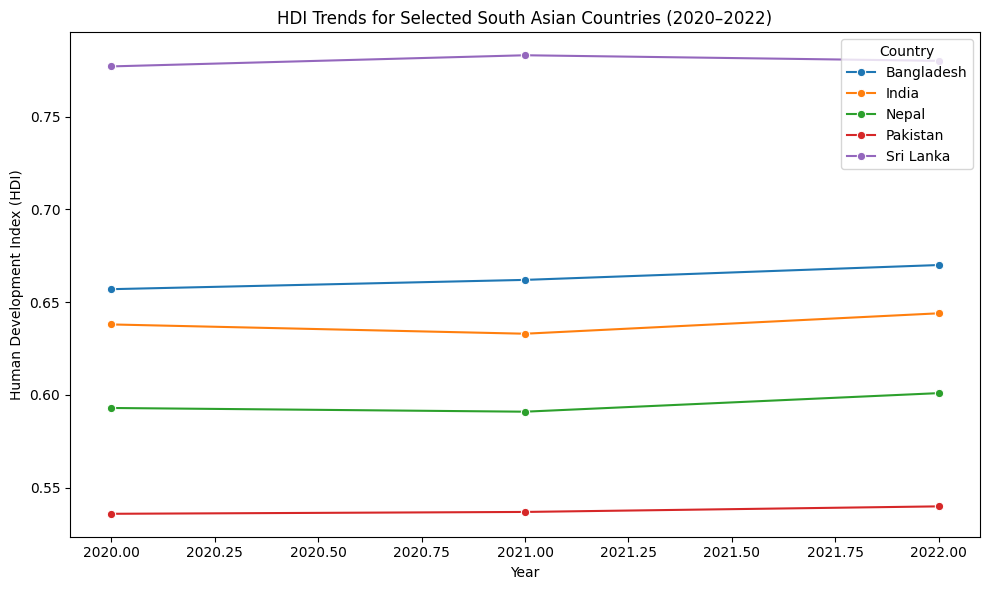

In [ ]:
#Ploting HDI values for each country across the years 2020, 2021, and 2022
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.lineplot(
    data=country_trends,
    x='year',
    y='hdi',
    hue='country',
    marker='o'
)
plt.title("HDI Trends for Selected South Asian Countries (2020–2022)")
plt.xlabel("Year")
plt.ylabel("Human Development Index (HDI)")
plt.legend(title="Country")
plt.tight_layout()
plt.show()


No. B: Generate Visualization

In [ ]:
# Mapping countries to regions manually
africa_iso3 = [
    'DZA', 'AGO', 'BEN', 'BWA', 'BFA', 'BDI', 'CPV', 'CMR', 'CAF', 'TCD', 'COM', 'COG',
    'CIV', 'COD', 'DJI', 'EGY', 'GNQ', 'ERI', 'SWZ', 'ETH', 'GAB', 'GMB', 'GHA', 'GIN',
    'GNB', 'KEN', 'LSO', 'LBR', 'LBY', 'MDG', 'MWI', 'MLI', 'MRT', 'MUS', 'MAR', 'MOZ',
    'NAM', 'NER', 'NGA', 'RWA', 'STP', 'SEN', 'SYC', 'SLE', 'SOM', 'ZAF', 'SSD', 'SDN',
    'TZA', 'TGO', 'TUN', 'UGA', 'ZMB', 'ZWE'
]

# Asia ISO3 codes
asia_iso3 = [
    'AFG', 'ARM', 'AZE', 'BHR', 'BGD', 'BTN', 'BRN', 'KHM', 'CHN', 'GEO', 'IND', 'IDN',
    'IRN', 'IRQ', 'ISR', 'JPN', 'JOR', 'KAZ', 'KWT', 'KGZ', 'LAO', 'LBN', 'MYS', 'MDV',
    'MNG', 'MMR', 'NPL', 'PRK', 'OMN', 'PAK', 'PSE', 'PHL', 'QAT', 'SAU', 'SGP', 'KOR',
    'LKA', 'SYR', 'TJK', 'THA', 'TLS', 'TUR', 'TKM', 'ARE', 'UZB', 'VNM', 'YEM', 'HKG'
]

# Europe ISO3 codes
europe_iso3 = [
    'ALB', 'AND', 'AUT', 'BLR', 'BEL', 'BIH', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST',
    'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'ISL', 'IRL', 'ITA', 'XKX', 'LVA', 'LIE', 'LTU',
    'LUX', 'MLT', 'MDA', 'MCO', 'MNE', 'NLD', 'MKD', 'NOR', 'POL', 'PRT', 'ROU', 'RUS',
    'SMR', 'SRB', 'SVK', 'SVN', 'ESP', 'SWE', 'CHE', 'UKR', 'GBR'
]

# North America ISO3 codes
north_america_iso3 = [
    'ATG', 'BHS', 'BRB', 'BLZ', 'CAN', 'CRI', 'CUB', 'DMA', 'DOM', 'SLV', 'GRD', 'GTM',
    'HTI', 'HND', 'JAM', 'MEX', 'NIC', 'PAN', 'KNA', 'LCA', 'VCT', 'TTO', 'USA'
]

# South America ISO3 codes
south_america_iso3 = [
    'ARG', 'BOL', 'BRA', 'CHL', 'COL', 'ECU', 'GUY', 'PRY', 'PER', 'SUR', 'URY', 'VEN'
]

# Oceania ISO3 codes
oceania_iso3 = [
    'AUS', 'FJI', 'KIR', 'MHL', 'FSM', 'NRU', 'NZL', 'PLW', 'PNG', 'WSM', 'SLB', 'TON',
    'TUV', 'VUT'
]

# Optional: Middle East (some countries overlap with Asia)
middle_east_iso3 = [
    'BHR', 'CYP', 'EGY', 'IRN', 'IRQ', 'ISR', 'JOR', 'KWT', 'LBN', 'OMN', 'PSE', 'QAT',
    'SAU', 'SYR', 'TUR', 'ARE', 'YEM'
]


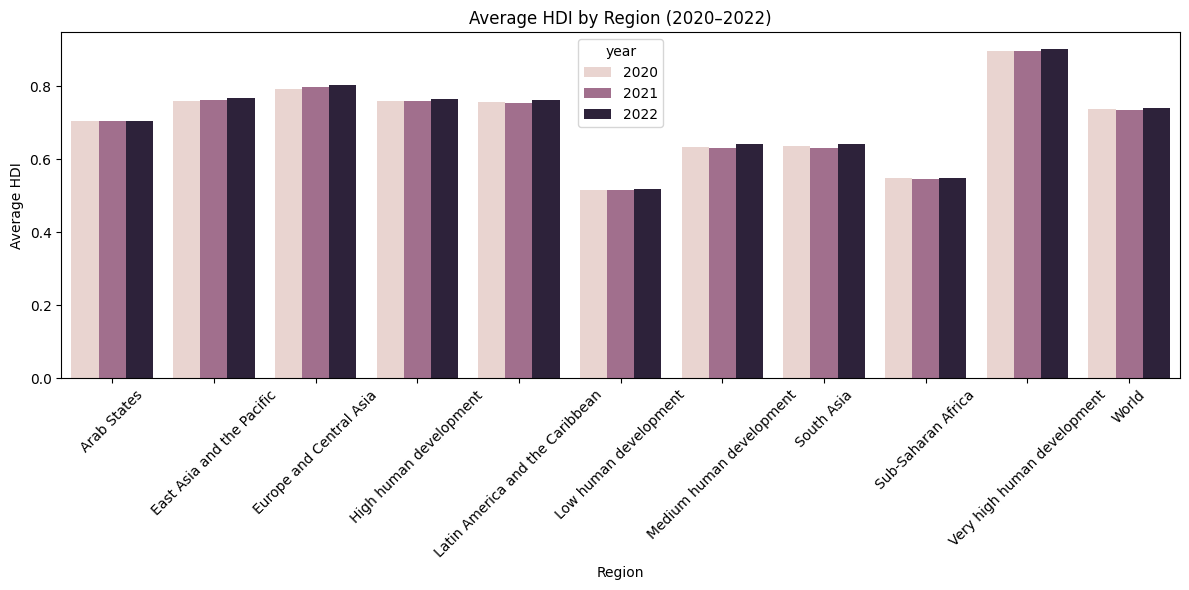

In [ ]:
# Bar Chart: Average HDI by Region (2020–2022)
# Filter for regional aggregates using 'iso3' codes starting with 'ZZ'
regional_data = hdi_problem1B[hdi_problem1B['iso3'].str.startswith('ZZ', na=False)]

region_year_avg = (
    regional_data
    .groupby(['country', 'year'])['hdi']
    .mean()
    .reset_index()
)

#Plotting

plt.figure(figsize=(12,6))
sns.barplot(
    data=region_year_avg,
    x='country',
    y='hdi',
    hue='year'
)
plt.title("Average HDI by Region (2020–2022)")
plt.xlabel("Region")
plt.ylabel("Average HDI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

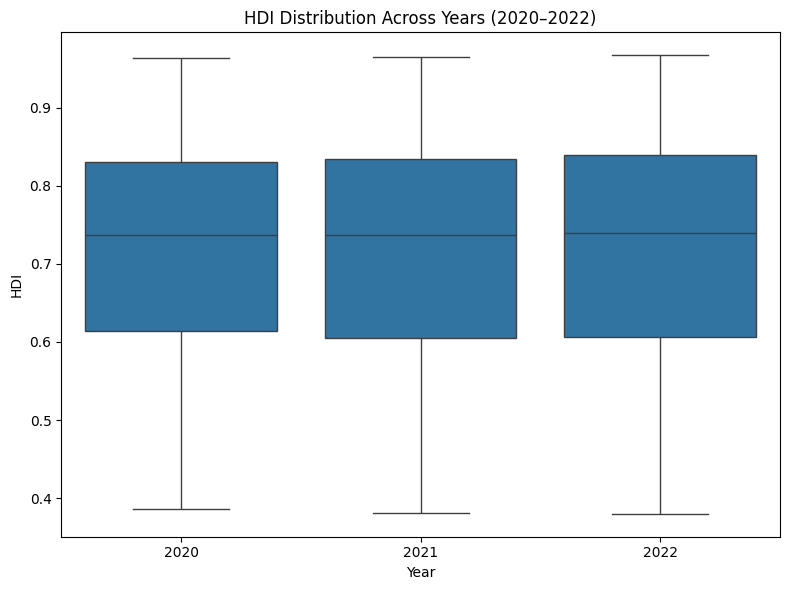

In [ ]:
#Box Plot: HDI Distribution for 2020, 2021, and 2022
plt.figure(figsize=(8,6))
sns.boxplot(
    data=hdi_problem1B,
    x='year',
    y='hdi'
)
plt.title("HDI Distribution Across Years (2020–2022)")
plt.xlabel("Year")
plt.ylabel("HDI")
plt.tight_layout()
plt.show()

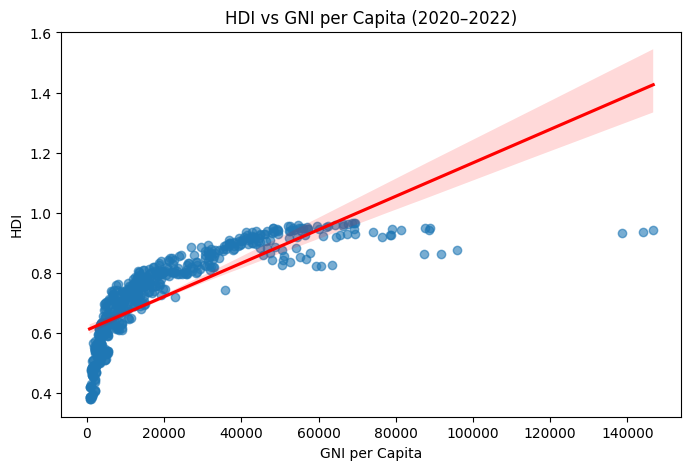

In [ ]:
#Scatter Plot: HDI vs. GNI per Capita

# Check if GNI per Capita column exists
if 'gross_inc_percap' in hdi_problem1B.columns:

    # Convert GNI column to numeric (if needed)
    hdi_problem1B['gross_inc_percap'] = pd.to_numeric(
        hdi_problem1B['gross_inc_percap'], errors='coerce'
    )


    # Create scatter plot
    plt.figure(figsize=(8,5))
    plt.scatter(
        hdi_problem1B['gross_inc_percap'],  # X-axis
        hdi_problem1B['hdi'],               # Y-axis
        alpha=0.6                     # Transparency for overlapping points
    )

    # Add regression line
    sns.regplot(
        data=hdi_problem1B,
        x='gross_inc_percap',
        y='hdi',
        scatter=False,
        color='red'
    )

    # Add labels and title
    plt.title('HDI vs GNI per Capita (2020–2022)')
    plt.xlabel('GNI per Capita')
    plt.ylabel('HDI')
    plt.show()

else:
    print("GNI per Capita variable not available in the dataset.")

Task 4: Short Analysis Questions

In [ ]:
#1st Question: Which countries show the greatest improvement in HDI from 2020 to 2022?

hdi_change = (
    hdi_problem1B
    .pivot(index='country', columns='year', values='hdi')
)

hdi_change['change_2020_2022'] = hdi_change[2022] - hdi_change[2020]

hdi_change.sort_values(by='change_2020_2022', ascending=False).head()

year,2020,2021,2022,change_2020_2022
country,,,,
Andorra,0.843,0.855,0.884,0.041
Azerbaijan,0.722,0.738,0.760,0.038
Ecuador,0.734,0.746,0.765,0.031
Maldives,0.737,0.753,0.762,0.025
Mexico,0.757,0.757,0.781,0.024


In [ ]:
#2nd Question: Did any countries experience a decline in HDI? Provide possible reasons.

hdi_change.sort_values(by='change_2020_2022').head()

year,2020,2021,2022,change_2020_2022
country,,,,
Timor-Leste,0.633,0.574,0.566,-0.067
Ukraine,0.762,0.755,0.734,-0.028
Afghanistan,0.488,0.473,0.462,-0.026
Namibia,0.634,0.616,0.610,-0.024
Lebanon,0.742,0.725,0.723,-0.019


Answer:
Some Possible reasons are COVID-19, Healthcare strain, Economic contraction

In [ ]:
#3rd Question: Which region has the highest and lowest average HDI across these three years?
region_avg = (
    hdi_problem1B
    .groupby('country')['hdi']
    .mean()
    .sort_values(ascending=False)
)

region_avg


,hdi
country,
Norway,0.964333
Switzerland,0.963000
Iceland,0.957000
"Hong Kong, China (SAR)",0.956667
Germany,0.948667
...,...
Chad,0.394333
Niger,0.391333
Central African Republic,0.387667


4th Question: Discuss how global events (e.g., the COVID-19 pandemic) may have affected HDI trends during this period.

Due to disturbance in education, income and healthcare, the COVID-19 had a negative impact on HDI. In 2022, economies opened again and stability of education system was seen.

#Problem-2 : Advanced HDI Exploration

Task:1 - Create South Asia Subset

In [ ]:
#Define the list of South Asian countries
south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

In [ ]:
#Filter the HDI dataset to include only these countries
hdi_southasia = df[df['country'].isin(south_asia_countries)].copy()
hdi_southasia.shape

(264, 29)

In [ ]:
#Saving the file
hdi_southasia.to_csv("HDI_SouthAsia.csv", index=False)

Task:2 - Composite Development Score

In [ ]:
#Create a new metric
hdi_southasia['Composite Score'] = (
    0.30 * hdi_southasia['life_expectancy'] +
    0.30 * hdi_southasia['gross_inc_percap']
)

In [ ]:
#Ranking South Asian countries based on Composite Score.
southasia_latest = hdi_southasia[hdi_southasia['year']==2022].copy()
southasia_ranked = southasia_latest.sort_values(
    by='Composite Score', ascending=False
)
southasia_ranked[['country', 'Composite Score', 'hdi']]

,country,Composite Score,hdi
5476,Sri Lanka,3799.859835,0.777
3529,Maldives,3723.426396,0.737
658,Bhutan,2990.462574,0.675
2572,India,1847.941960,0.638
460,Bangladesh,1768.430664,0.657
4387,Pakistan,1493.568123,0.536
4090,Nepal,1162.337875,0.593
31,Afghanistan,614.813632,0.488


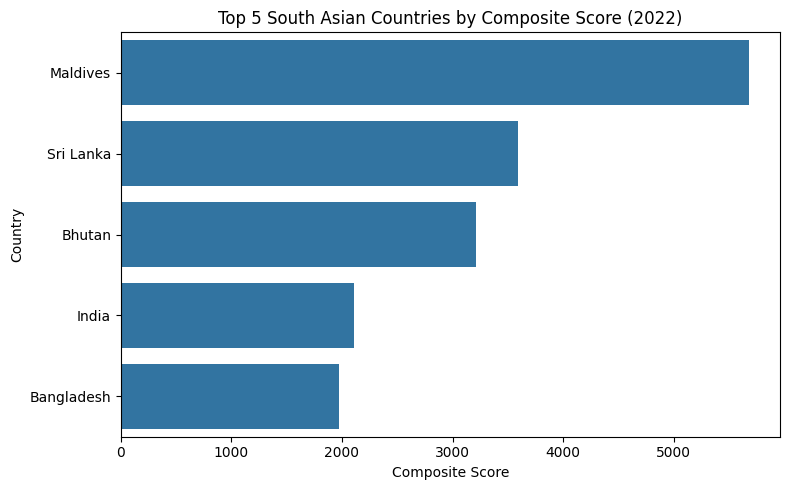

In [ ]:
#Plotting Top 5 Countries
top5 = southasia_ranked.head(5)
plt.figure(figsize=(8,5))
sns.barplot(
    data=top5,
    x='Composite Score',
    y='country'
)
plt.title("Top 5 South Asian Countries by Composite Score (2022)")
plt.xlabel("Composite Score")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


Compare the ranking of countries by Composite Score with their HDI ranking and discuss any
differences.

->HDI includes Education whereas Composite_Score uses only health and income. That is why Composite_Score ranking may vary from HDI.

Task:3 - Outlier Detection

In [ ]:
#Detecting outliers in HDI and GNI per Capita
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)
southasia_latest['HDI_outlier'] = detect_outliers(southasia_latest['hdi'])
southasia_latest['GNI_outlier'] = detect_outliers(southasia_latest['gross_inc_percap'])

/tmp/ipython-input-4140909888.py:3: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(


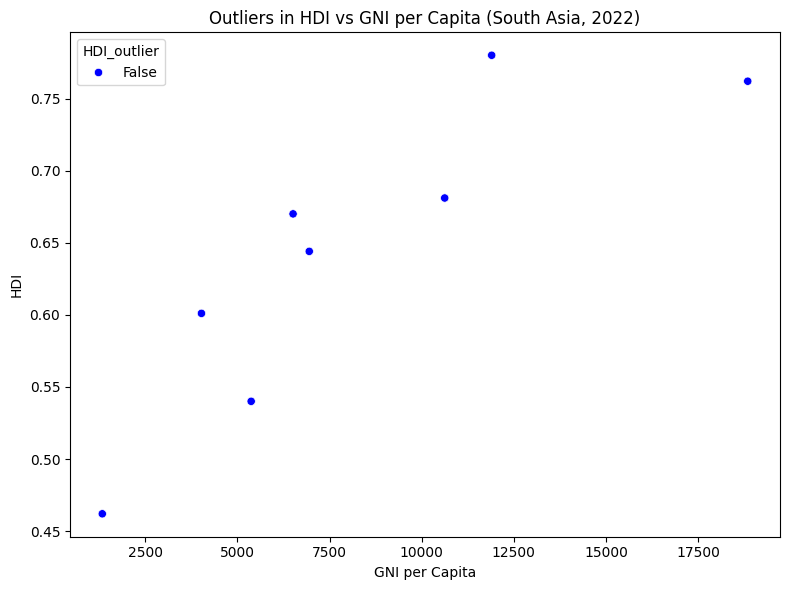

In [ ]:
#Creating scatter plot of GNI per Capita vs HDI
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=southasia_latest,
    x='gross_inc_percap',
    y='hdi',
    hue='HDI_outlier',
    palette=['blue', 'red']
)
plt.title("Outliers in HDI vs GNI per Capita (South Asia, 2022)")
plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.tight_layout()
plt.show()

Discuss why the identified countries stand out as outliers.

->Due to high income or HDI compared to regional peers, the indentified countries stand out as outliers.

Task:4 - Exploring Metric Relationships

In [ ]:
#Selecting two HDI components
metrics = ['gender_development', 'life_expectancy']

In [ ]:
#Computing Pearson correlation of each metric with HDI.
for metric in metrics:
    corr = southasia_latest[metric].corr(southasia_latest['hdi'])
    print(f"Correlation between HDI and {metric}: {corr:.3f}")

Correlation between HDI and gender_development: 0.885
Correlation between HDI and life_expectancy: 0.928


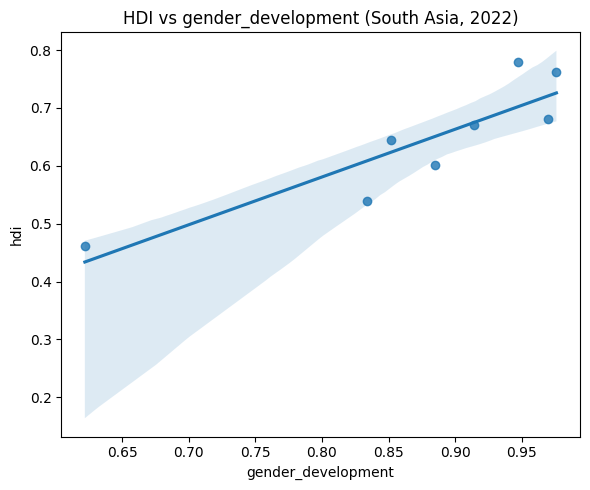

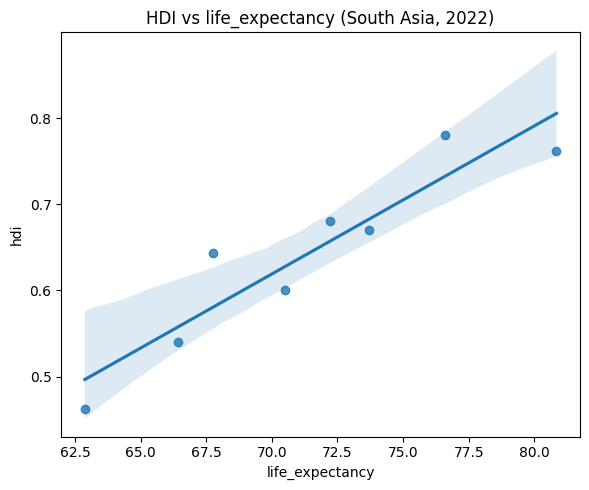

In [ ]:
#Creating scatter plot
for metric in metrics:
    plt.figure(figsize=(6,5))
    sns.regplot(
        data=southasia_latest,
        x=metric,
        y='hdi'
    )
    plt.title(f"HDI vs {metric} (South Asia, 2022)")
    plt.tight_layout()
    plt.show()


Which metric is most strongly related to HDI and shows the weakest relationship with HDI??

->The metric with higher correlation is strongly related to HDI.

Task:5 - Gap Analysis

In [ ]:
#New metric Creation
southasia_latest['GNI_HDI_Gap'] = (
    southasia_latest['gross_inc_percap'] - southasia_latest['hdi']
)

In [ ]:
#Ranking South Asian countries by GNI HDI Gap in descending and ascending order.
#descending
southasia_latest.sort_values(by='GNI_HDI_Gap', ascending=False)[
    ['country', 'GNI_HDI_Gap']
]

,country,GNI_HDI_Gap
3531,Maldives,18846.030190
5478,Sri Lanka,11898.718470
660,Bhutan,10624.192880
2574,India,6949.882798
462,Bangladesh,6510.452178
4389,Pakistan,5373.730423
4092,Nepal,4024.953685
33,Afghanistan,1334.743733


In [ ]:
#ascending
southasia_latest.sort_values(by='GNI_HDI_Gap', ascending=True)[
    ['country', 'GNI_HDI_Gap']
]

,country,GNI_HDI_Gap
33,Afghanistan,1334.743733
4092,Nepal,4024.953685
4389,Pakistan,5373.730423
462,Bangladesh,6510.452178
2574,India,6949.882798
660,Bhutan,10624.192880
5478,Sri Lanka,11898.718470
3531,Maldives,18846.030190


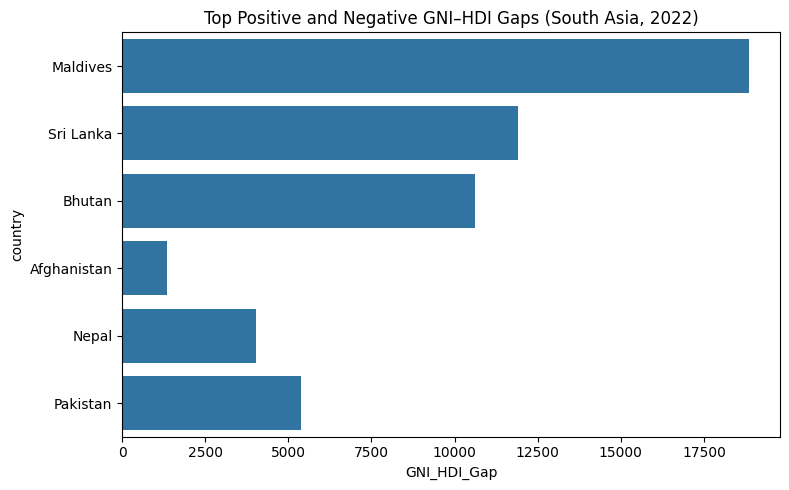

In [ ]:
#Plotting top 3 positive and negative
top_positive = southasia_latest.sort_values(
    by='GNI_HDI_Gap', ascending=False
).head(3)

top_negative = southasia_latest.sort_values(
    by='GNI_HDI_Gap'
).head(3)
gap_df = pd.concat([top_positive, top_negative])

plt.figure(figsize=(8,5))
sns.barplot(
    data=gap_df,
    x='GNI_HDI_Gap',
    y='country'
)

plt.title("Top Positive and Negative GNI–HDI Gaps (South Asia, 2022)")
plt.tight_layout()
plt.show()

Discuss the implications of the gap, e.g., cases where GNI is high but HDI is lower than expected.

->Large positive gap

#Problem-3: Comparative Regional Analysis

Task:1 - Create Middle East Subset

In [ ]:
#Defining List of middle east countries
south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

middle_east_countries = [
    "Bahrain", "Iran", "Iraq", "Israel", "Jordan",
    "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
    "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"
]

In [ ]:
#Filtering dataset from Problem 1b
southasia_2020_2022 = hdi_problem1B[
    hdi_problem1B['country'].isin(south_asia_countries)
].copy()

middleeast_2020_2022 = hdi_problem1B[
    hdi_problem1B['country'].isin(middle_east_countries)
].copy()

In [ ]:
#Saving the subsets
southasia_2020_2022.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
middleeast_2020_2022.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)

Task:2 - Descriptive Statistics

In [ ]:
#COmputing mean and standard deviation
southasia_stats = southasia_2020_2022['hdi'].agg(['mean', 'std'])
middleeast_stats = middleeast_2020_2022['hdi'].agg(['mean', 'std'])

southasia_stats, middleeast_stats

(mean    0.639583
 std     0.098273
 Name: hdi, dtype: float64,
 mean    0.788909
 std     0.141295
 Name: hdi, dtype: float64)

In [ ]:
#Identification
print("Middle east performs better on average than south asia.")

Middle east performs better on average than south asia.


Task:3 - Top and Bottom performer

In [ ]:
#Identifying top and bottom in each region

southasia_avg = (
    southasia_2020_2022
    .groupby('country')['hdi']
    .mean()
    .sort_values()
)

middleeast_avg = (
    middleeast_2020_2022
    .groupby('country')['hdi']
    .mean()
    .sort_values()
)

southasia_top_bottom = pd.concat([
    southasia_avg.head(3),
    southasia_avg.tail(3)
])

middleeast_top_bottom = pd.concat([
    middleeast_avg.head(3),
    middleeast_avg.tail(3)
])
#Top 3 countries

print("\nSouth Asia – Top 3 Countries by HDI:")
southasia_avg.tail(3)


South Asia – Top 3 Countries by HDI:


,hdi
country,
Bhutan,0.677667
Maldives,0.750667
Sri Lanka,0.780000


In [ ]:
#Bottom 3 countries
print("South Asia – Bottom 3 Countries by HDI:")
southasia_avg.head(3)

South Asia – Bottom 3 Countries by HDI:


,hdi
country,
Afghanistan,0.474333
Pakistan,0.537667
Nepal,0.595000


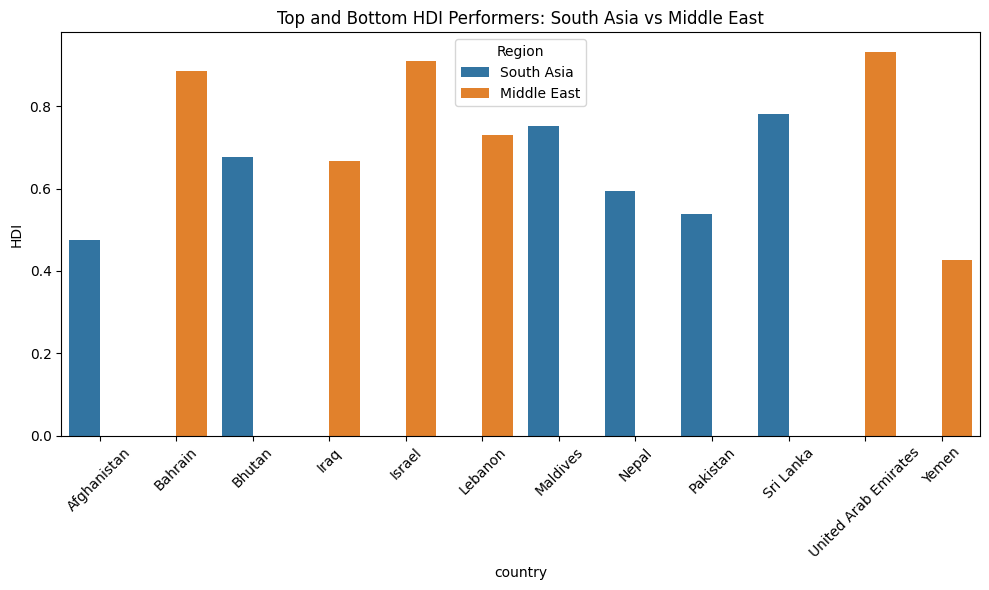

In [ ]:
#Bar chart comparing top and bottom performer
compare_df = pd.DataFrame({
    'South Asia': southasia_top_bottom,
    'Middle East': middleeast_top_bottom
}).reset_index()
compare_df = compare_df.melt(
    id_vars='country',
    var_name='Region',
    value_name='HDI'
)
plt.figure(figsize=(10,6))
sns.barplot(
    data=compare_df,
    x='country',
    y='HDI',
    hue='Region'
)
plt.xticks(rotation=45)
plt.title("Top and Bottom HDI Performers: South Asia vs Middle East")
plt.tight_layout()
plt.show()


Task:4 - Metric Comparison

In [ ]:
metrics = ['gender_development', 'life_expectancy', 'gross_inc_percap']
metric_compare = (
    hdi_problem1B
    .assign(Region=lambda x: np.where(
        x['country'].isin(south_asia_countries), 'South Asia',
        np.where(x['country'].isin(middle_east_countries), 'Middle East', None)
    ))
    .dropna(subset=['Region'])
    .groupby('Region')[metrics]
    .mean()
    .reset_index()
)

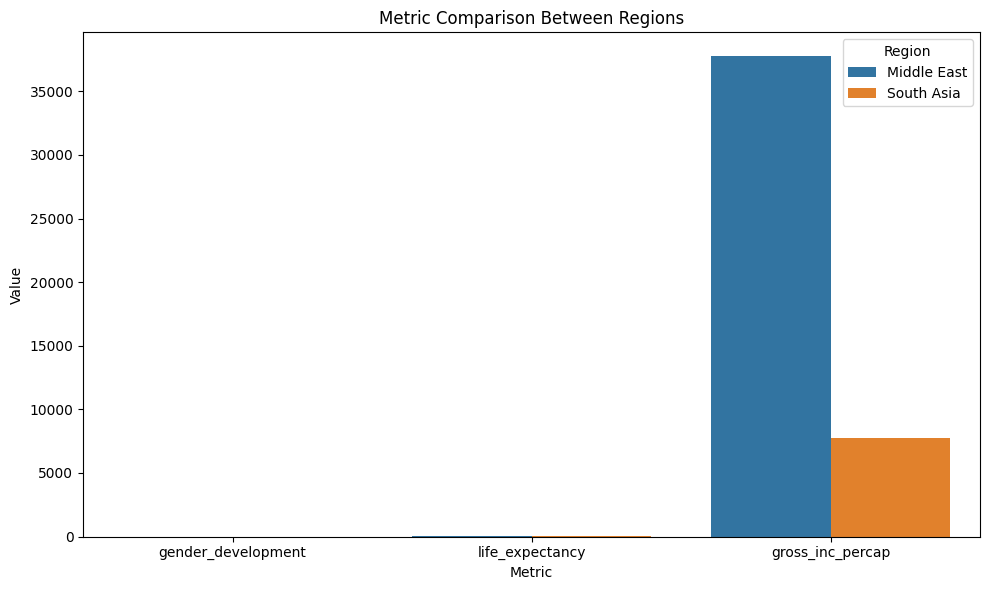

In [ ]:
metric_compare_melted = metric_compare.melt(
    id_vars='Region',
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=metric_compare_melted,
    x='Metric',
    y='Value',
    hue='Region'
)
plt.title("Metric Comparison Between Regions")
plt.tight_layout()
plt.show()


Identify which metric shows the greatest disparity between regions.

-> The GNI per capita shows the greatest disparity between South Asia and the Middle East.

Task:5 - HDI disparity

In [ ]:
# Computing HDI ranges
def hdi_range(df):
    return df['hdi'].max() - df['hdi'].min()

southasia_range = hdi_range(southasia_2020_2022)
middleeast_range = hdi_range(middleeast_2020_2022)

print("South Asia HDI Range:", southasia_range)
print("Middle East HDI Range:", middleeast_range)


South Asia HDI Range: 0.321
Middle East HDI Range: 0.5130000000000001


In [ ]:
#Computing Coefficient
def hdi_cv(df):
    return df['hdi'].std() / df['hdi'].mean()

southasia_cv = hdi_cv(southasia_2020_2022)
middleeast_cv = hdi_cv(middleeast_2020_2022)

print("South Asia HDI Coefficient of Variation (CV):", southasia_cv)
print("Middle East HDI Coefficient of Variation (CV):", middleeast_cv)


South Asia HDI Coefficient of Variation (CV): 0.1536520924690084
Middle East HDI Coefficient of Variation (CV): 0.17910145193048382


Identify which region exhibits more variation in HDI.

-> The Middle East exhibits greater variation in HDI compared to South Asia.

Task:6 - Correlation Analysis

In [ ]:
#Computing correlations of HDI with gender development anf life expectancy
def correlation_analysis(df, region_name):
    for metric in ['gender_development', 'life_expectancy']:
        corr = df[metric].corr(df['hdi'])
        print(f"{region_name} | HDI vs {metric}: {corr:.3f}")
correlation_analysis(southasia_2020_2022, "South Asia")
correlation_analysis(middleeast_2020_2022, "Middle East")

South Asia | HDI vs gender_development: 0.874
South Asia | HDI vs life_expectancy: 0.939
Middle East | HDI vs gender_development: 0.936
Middle East | HDI vs life_expectancy: 0.933


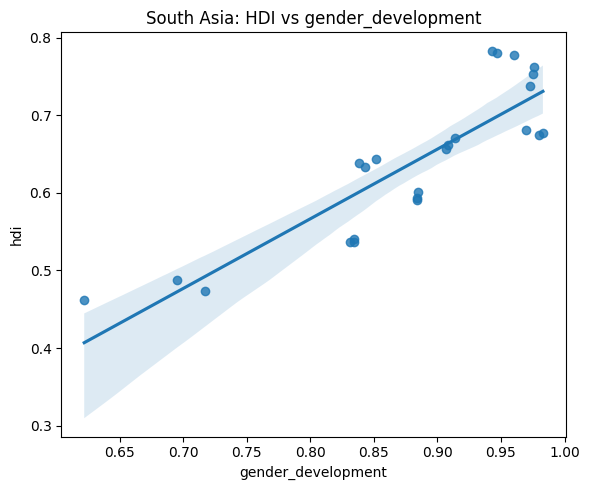

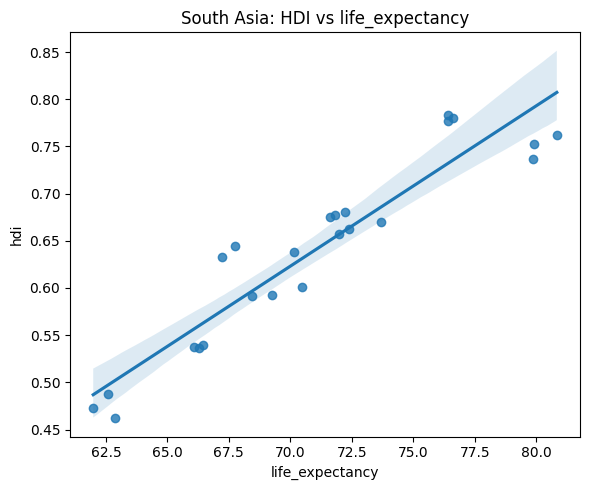

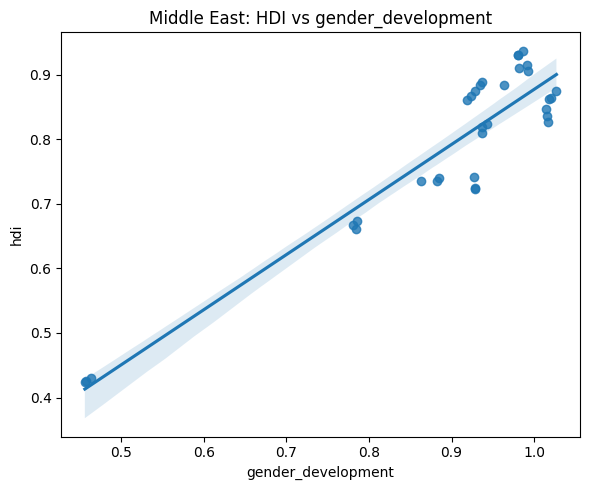

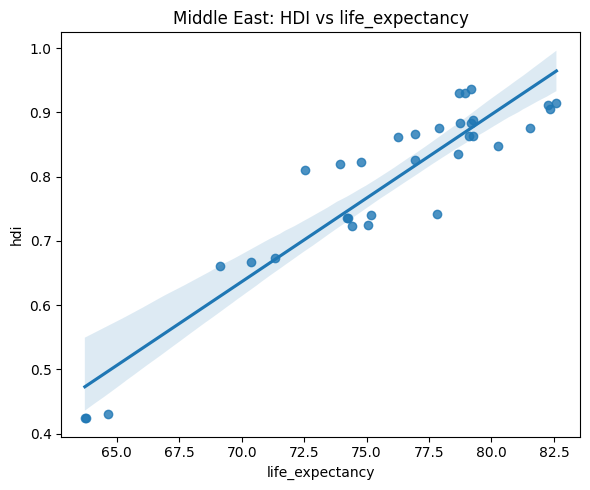

In [ ]:
#creating scatter plots with treadlines
for region_df, name in [
    (southasia_2020_2022, "South Asia"),
    (middleeast_2020_2022, "Middle East")
]:
    for metric in ['gender_development', 'life_expectancy']:
        plt.figure(figsize=(6,5))
        sns.regplot(
            data=region_df,
            x=metric,
            y='hdi'
        )
        plt.title(f"{name}: HDI vs {metric}")
        plt.tight_layout()
        plt.show()

In [ ]:
#interpretation





Task:7 - Outliers Detection

In [ ]:
#detectiong outliers in hdi and GNI
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)

/tmp/ipython-input-916251432.py:12: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(


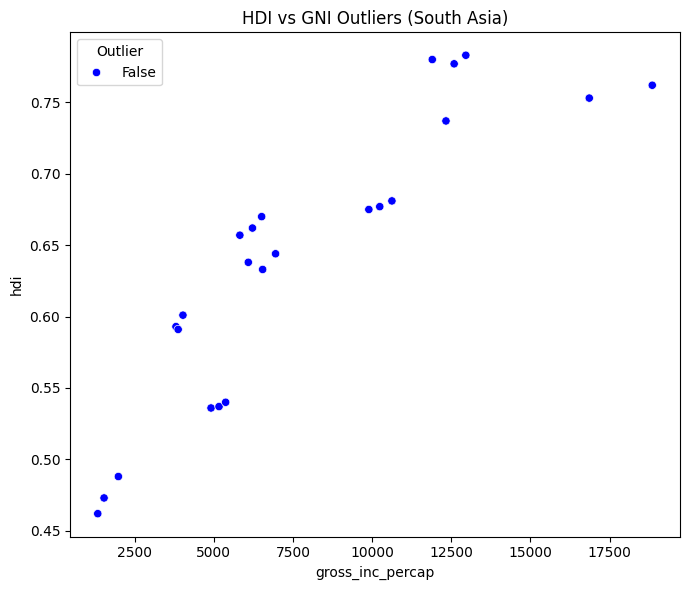

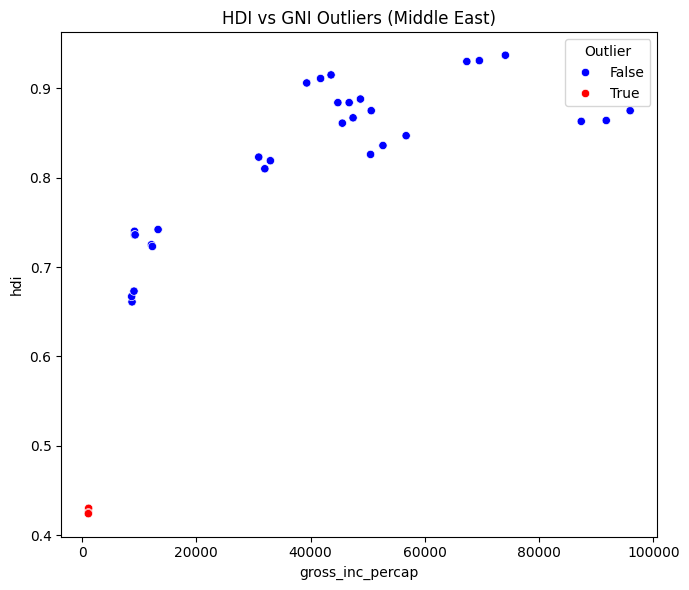

In [ ]:
#Creating scatter plot highlighting outliers
for region_df, name in [
    (southasia_2020_2022, "South Asia"),
    (middleeast_2020_2022, "Middle East")
]:
    region_df['Outlier'] = (
        detect_outliers(region_df['hdi']) |
        detect_outliers(region_df['gross_inc_percap'])
    )

    plt.figure(figsize=(7,6))
    sns.scatterplot(
        data=region_df,
        x='gross_inc_percap',
        y='hdi',
        hue='Outlier',
        palette=['blue', 'red']
    )
    plt.title(f"HDI vs GNI Outliers ({name})")
    plt.tight_layout()
    plt.show()